In [1]:
"""
================================
Tutorial 1: Simple Motor Imagery
================================

In this example, we will go through all the steps to make a simple BCI
classification task, downloading a dataset and using a standard classifier. We
choose the dataset 2a from BCI Competition IV, a motor imagery task. We will
use a CSP to enhance the signal-to-noise ratio of the EEG epochs and a LDA to
classify these signals.
"""

# Authors: Pedro L. C. Rodrigues, Sylvain Chevallier
#
# https://github.com/plcrodrigues/Workshop-MOABB-BCI-Graz-2019

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline

import moabb
from moabb.datasets import BNCI2014_001
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import LeftRightImagery


moabb.set_log_level("info")
warnings.filterwarnings("ignore")

In [2]:
##############################################################################
# Instantiating Dataset
# ---------------------
#
# The first thing to do is to instantiate the dataset that we want to analyze.
# MOABB has a list of many different datasets, each one containing all the
# necessary information for describing them, such as the number of subjects,
# size of trials, names of classes, etc.
#
# The dataset class has methods for:
#
# - downloading its files from some online source (e.g. Zenodo)
# - importing the data from the files in whatever extension they might be
#   (like .mat, .gdf, etc.) and instantiate a Raw object from the MNE package

dataset = BNCI2014_001()
dataset.subject_list = [1, 2, 3]

In [3]:
##############################################################################
# Accessing EEG Recording
# -----------------------
#
# As an example, we may access the EEG recording from a given session and a
# given run as follows:

sessions = dataset.get_data(subjects=[1])

In [4]:
##############################################################################
# This returns a MNE Raw object that can be manipulated. This might be enough
# for some users, since the pre-processing and epoching steps can be easily
# done via MNE. However, to conduct an assessment of several classifiers on
# multiple subjects, MOABB ends up being a more appropriate option.

subject = 1
session_name = "0train"
run_name = "0"
raw = sessions[subject][session_name][run_name]

In [5]:
##############################################################################
# Choosing a Paradigm
# -------------------
#
# Once we have instantiated a dataset, we have to choose a paradigm. This
# object is responsible for filtering the data, epoching it, and extracting
# the labels for each epoch. Note that each dataset comes with the names of
# the paradigms to which it might be associated. It would not make sense to
# process a P300 dataset with a MI paradigm object.

print(dataset.paradigm)

imagery


In [6]:
##############################################################################
# For the example below, we will consider the paradigm associated to
# left-hand/right-hand motor imagery task, but there are other options in
# MOABB for motor imagery, P300 or SSVEP.

paradigm = LeftRightImagery()

In [7]:
##############################################################################
# We may check the list of all datasets available in MOABB for using with this
# paradigm (note that BNCI2014_001 is in it)

print(paradigm.datasets)

[<moabb.datasets.bnci.BNCI2014_001 object at 0x122c7c190>, <moabb.datasets.bnci.BNCI2014_004 object at 0x177dc5a90>, <moabb.datasets.beetl.Beetl2021_A object at 0x177dc6ba0>, <moabb.datasets.beetl.Beetl2021_B object at 0x177dc63c0>, <moabb.datasets.gigadb.Cho2017 object at 0x177dc6cf0>, <moabb.datasets.dreyer2023.Dreyer2023 object at 0x177dc6f90>, <moabb.datasets.dreyer2023.Dreyer2023A object at 0x177dc6e40>, <moabb.datasets.dreyer2023.Dreyer2023B object at 0x177dc70e0>, <moabb.datasets.dreyer2023.Dreyer2023C object at 0x177dc7230>, <moabb.datasets.mpi_mi.GrosseWentrup2009 object at 0x177dc7380>, <moabb.datasets.Lee2019.Lee2019_MI object at 0x177dc74d0>, <moabb.datasets.liu2024.Liu2024 object at 0x177dc7620>, <moabb.datasets.physionet_mi.PhysionetMI object at 0x123d727b0>, <moabb.datasets.schirrmeister2017.Schirrmeister2017 object at 0x123d70590>, <moabb.datasets.bbci_eeg_fnirs.Shin2017A object at 0x123d72900>, <moabb.datasets.stieger2021.Stieger2021 object at 0x177dc7770>, <moabb.data

In [9]:
##############################################################################
# The data from a list of subjects could be preprocessed and return as a 3D
# numpy array `X`, follow a scikit-like format with the associated `labels`.
# The `meta` object contains all information regarding the subject, the
# session and the run associated to each trial.
X, labels, meta = paradigm.get_data(dataset=dataset, subjects=[1])
print(X, labels, meta)


[[[  6.12675343   4.80069492   1.8937593  ...  -1.80963356  -0.95822005
     0.10018214]
  [  5.58056783   3.78074325   1.02786715 ...  -1.32946883  -0.62293255
     0.06768451]
  [  7.43279059   5.46171881   2.11057866 ...  -0.57576039  -0.65376666
    -0.73565678]
  ...
  [  7.465582     3.39468294  -1.15504664 ...  -3.41820391  -2.94795975
    -2.31999583]
  [  5.00811146   1.58727604  -2.11582106 ...  -3.48512891  -2.69524861
    -1.68924441]
  [  8.01582351   4.2274779   -0.1410632  ...  -4.097163    -3.54158428
    -2.65380789]]

 [[ -0.7702083   -0.77995427  -1.51378905 ...  -9.44448146 -11.03344346
   -11.02605606]
  [ -1.33536169  -1.04522174  -0.87003607 ...  -8.77443588 -10.72309939
   -10.2110244 ]
  [  0.30316772   0.02742408  -1.01425588 ...  -9.24718849 -11.26148117
   -10.91802947]
  ...
  [ -6.81387658  -7.2220894   -7.60139055 ...  -4.96596411  -4.05442771
    -1.49866564]
  [ -7.61409517  -7.96167406  -7.99530206 ...  -1.37466745  -0.81559275
     0.62729322]
  [ -5.

In [10]:
##############################################################################
# Create Pipeline
# ---------------
#
# Our goal is to evaluate the performance of a given classification pipeline
# (or several of them) when it is applied to the epochs from the previously
# chosen dataset. We will consider a very simple classification pipeline in
# which the dimension of the epochs are reduced via a CSP step and then
# classified via a linear discriminant analysis.

pipeline = make_pipeline(CSP(n_components=8), LDA())


In [11]:
##############################################################################
# Evaluation
# ----------
#
# To evaluate the score of this pipeline, we use the `evaluation` class. When
# instantiating it, we say which paradigm we want to consider, a list with the
# datasets to analyze, and whether the scores should be recalculated each time
# we run the evaluation or if MOABB should create a cache file.
#
# Note that there are different ways of evaluating a classifier; in this
# example, we choose `WithinSessionEvaluation`, which consists of doing a
# cross-validation procedure where the training and testing partitions are from
# the same recording session of the dataset. We could have used
# `CrossSessionEvaluation`, which takes all but one session as training
# partition and the remaining one as testing partition.

evaluation = WithinSessionEvaluation(
    paradigm=paradigm,
    datasets=[dataset],
    overwrite=True,
    hdf5_path=None,
)


In [12]:
##############################################################################
# We obtain the results in the form of a pandas dataframe

results = evaluation.process({"csp+lda": pipeline})

##############################################################################
# The results are stored in locally, to avoid recomputing the results each time.
# It is saved in `hdf5_path` if defined or in ~/mne_data/results  otherwise.
# To export the results in CSV:

results.to_csv("./results_part2-1.csv")

##############################################################################
# To load previously obtained results saved in CSV

results = pd.read_csv("./results_part2-1.csv")

BNCI2014-001-WithinSession: 100%|██████████| 3/3 [00:10<00:00,  3.40s/it]
2025-12-18 09:15:38,924 INFO MainThread moabb.evaluations.base csp+lda | BNCI2014-001 | 1 | 0train: Score 0.923
2025-12-18 09:15:38,981 INFO MainThread moabb.evaluations.base csp+lda | BNCI2014-001 | 1 | 1test: Score 0.957
2025-12-18 09:15:39,039 INFO MainThread moabb.evaluations.base csp+lda | BNCI2014-001 | 2 | 0train: Score 0.601
2025-12-18 09:15:39,095 INFO MainThread moabb.evaluations.base csp+lda | BNCI2014-001 | 2 | 1test: Score 0.593
2025-12-18 09:15:39,151 INFO MainThread moabb.evaluations.base csp+lda | BNCI2014-001 | 3 | 0train: Score 0.992
2025-12-18 09:15:39,205 INFO MainThread moabb.evaluations.base csp+lda | BNCI2014-001 | 3 | 1test: Score 0.995


2025-12-18 09:15:51,268 INFO MainThread matplotlib.category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-12-18 09:15:51,270 INFO MainThread matplotlib.category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


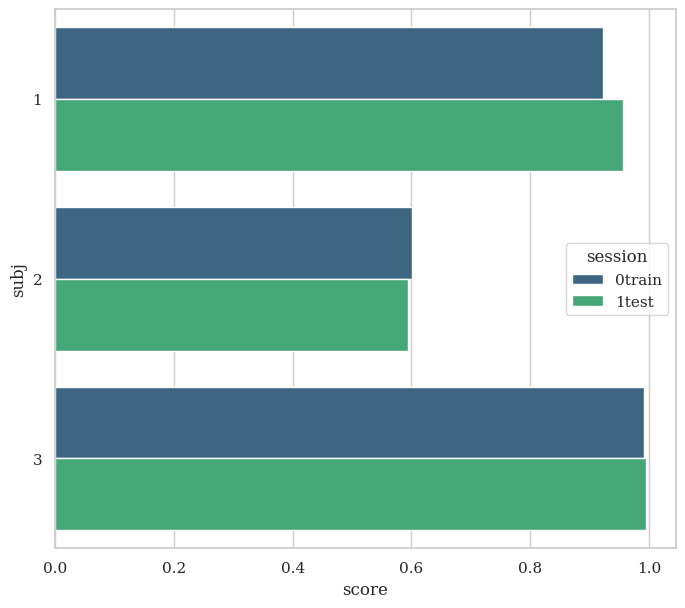

In [13]:
##############################################################################
# Plotting Results
# ----------------
#
# We create a figure with the seaborn package comparing the classification
# score for each subject on each session. Note that the 'subject' field from
# the `results` is given in terms of integers, but seaborn accepts only
# strings for its labeling. This is why we create the field 'subj'.

fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()